In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

🔗 Dataset Link:  
https://www.kaggle.com/datasets/likithagedipudi/starbucks-customer-ordering-patterns


In [ ]:
df = pd.read_csv("spotify_data.csv")

# Preview dataset
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [ ]:
features = ["tempo", "loudness", "energy", "speechiness", "valence"]

df[features].head()

,tempo,loudness,energy,speechiness,valence
0,166.969,-1.828,0.910,0.0525,0.814
1,174.003,-5.559,0.737,0.0868,0.816
2,99.488,-13.879,0.131,0.0362,0.368
3,171.758,-12.178,0.326,0.0395,0.227
4,140.576,-21.150,0.225,0.0456,0.390


In [ ]:
stats = df[features].agg(['mean', 'std', 'min', 'max']).T

stats.columns = ["Mean", "Std_Deviation", "Min", "Max"]
stats

,Mean,Std_Deviation,Min,Max
tempo,117.666585,30.898907,30.37900,242.903
loudness,-9.569885,5.998204,-52.45700,3.744
energy,0.570958,0.263456,0.00002,0.999
speechiness,0.120765,0.185518,0.02220,0.967
valence,0.454917,0.260065,0.00000,1.000


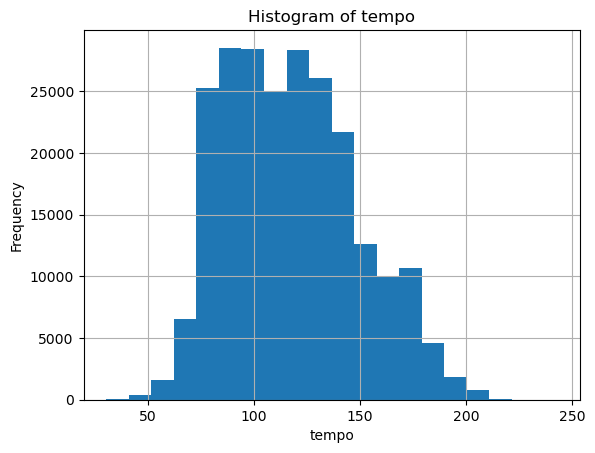

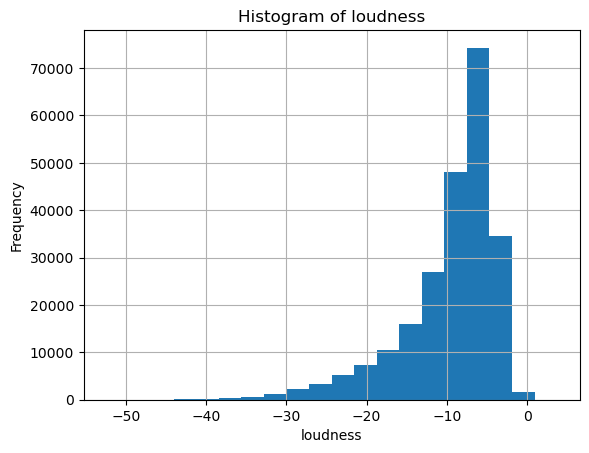

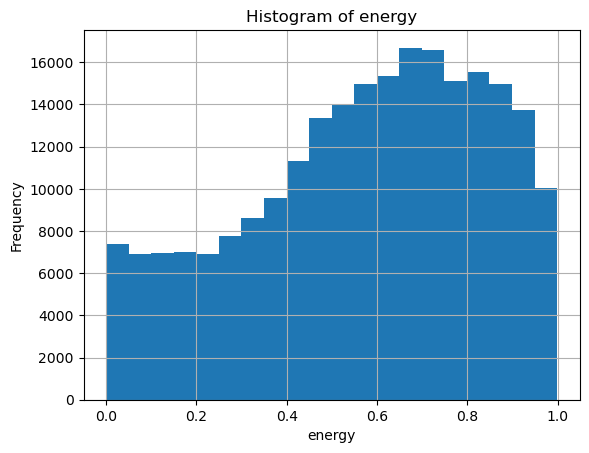

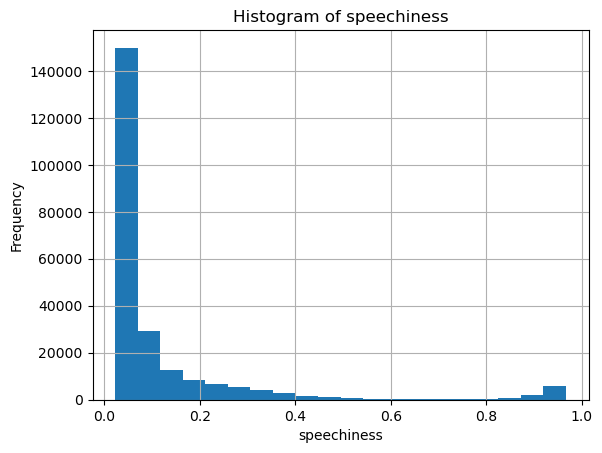

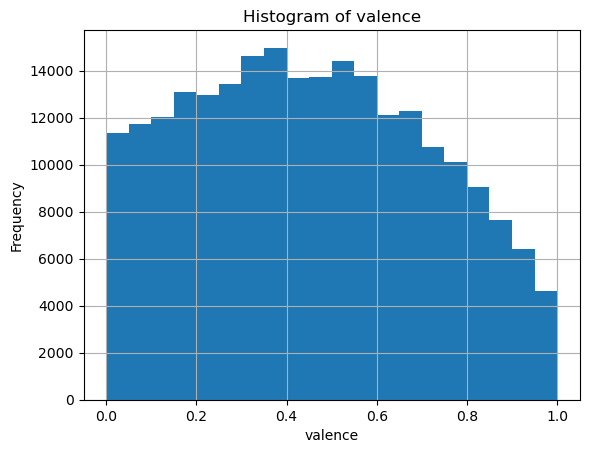

In [ ]:
for feature in features:
    plt.figure()
    df[feature].hist(bins=20)
    plt.title(f"Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

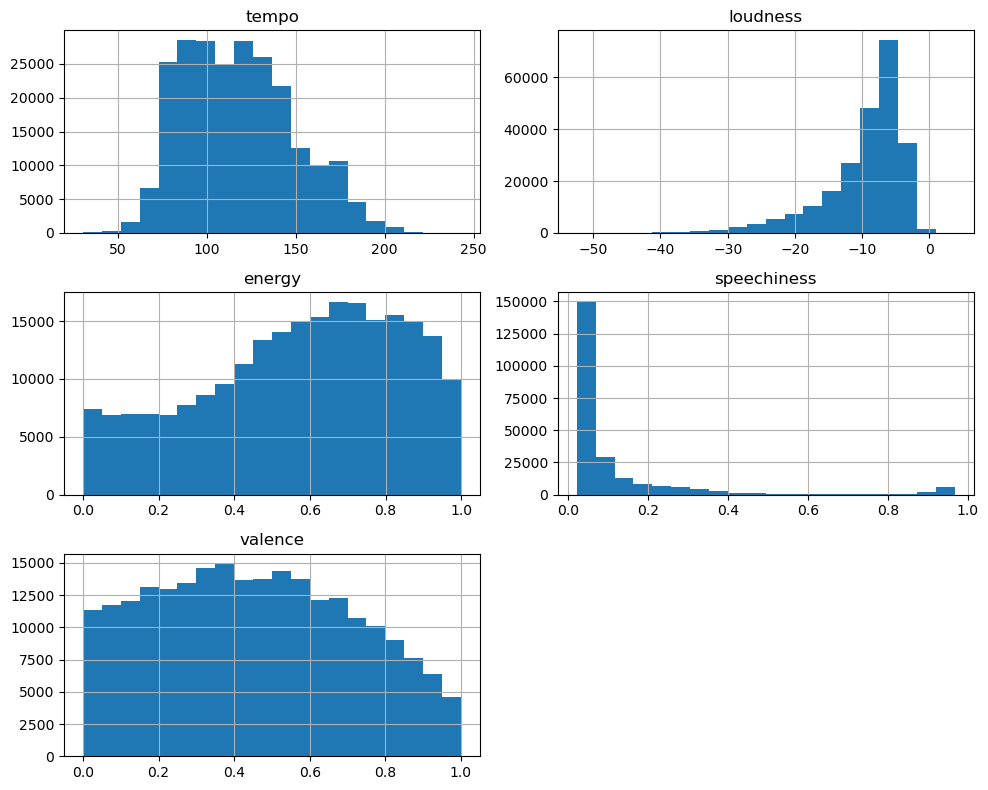

In [ ]:
df[features].hist(bins=20, figsize=(10,8))
plt.tight_layout()
plt.show()

In [ ]:
df[features].std().sort_values(ascending=False)

tempo          30.898907
loudness        5.998204
energy          0.263456
valence         0.260065
speechiness     0.185518
dtype: float64

Highest Variance Signal

The tempo feature has the highest variance among all analyzed signals because it shows the largest standard deviation. This indicates that the beat speed of songs varies greatly across the dataset. Some tracks have slow tempos while others are very fast, resulting in a wide spread of values. In DSP terms, this means the frequency component of the signal changes significantly between samples.

Most Stable Signal

The speechiness feature is the most stable signal because it has the smallest variation compared to the other features. Most songs contain low speech content, causing the values to cluster within a small range. This indicates consistent signal characteristics, meaning the signal type remains mostly musical rather than speech-based throughout the dataset.

In [ ]:
numeric_df = df.select_dtypes(include='number')

# Choose first 5 features (or edit manually)
features = numeric_df.columns[:5]

data = numeric_df[features]

print("Selected Features:")
print(features)

Selected Features:
Index(['popularity', 'acousticness', 'danceability', 'duration_ms', 'energy'], dtype='object')


In [ ]:
corr_matrix = data.corr()

print("Correlation Matrix:")
corr_matrix

Correlation Matrix:


,popularity,acousticness,danceability,duration_ms,energy
popularity,1.000000,-0.381295,0.256564,0.002348,0.248922
acousticness,-0.381295,1.000000,-0.364546,0.011203,-0.725576
danceability,0.256564,-0.364546,1.000000,-0.125781,0.325807
duration_ms,0.002348,0.011203,-0.125781,1.000000,-0.030550
energy,0.248922,-0.725576,0.325807,-0.030550,1.000000


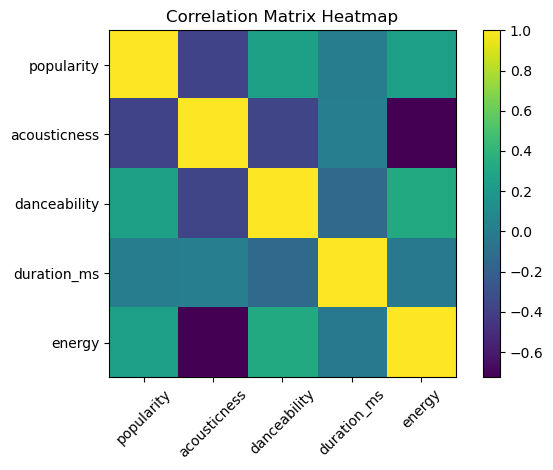

In [ ]:
plt.figure()
plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(range(len(features)), features, rotation=45)
plt.yticks(range(len(features)), features)

plt.title("Correlation Matrix Heatmap")

plt.tight_layout()
plt.show()

Interpretation:

popularity vs acousticness = -0.381 (Weak)
popularity vs danceability = 0.257 (Weak)
popularity vs duration_ms = 0.002 (Weak)
popularity vs energy = 0.249 (Weak)
acousticness vs danceability = -0.365 (Weak)
acousticness vs duration_ms = 0.011 (Weak)
acousticness vs energy = -0.726 (Strong)
danceability vs duration_ms = -0.126 (Weak)
danceability vs energy = 0.326 (Weak)
duration_ms vs energy = -0.031 (Weak)

Summary:
- Strong correlation: acousticness vs energy (negative relationship)
- Weak correlation: duration vs popularity (almost no relationship)
- Most features show weak relationships, meaning low dependency

In [ ]:
# Define filter conditions
filtered_df = df[(df['energy'] < 0.5) & (df['loudness'] > -10)]

# Print dataset sizes
print("Original size:", df.shape[0])
print("Filtered size:", filtered_df.shape[0])

Original size: 232725
Filtered size: 22215


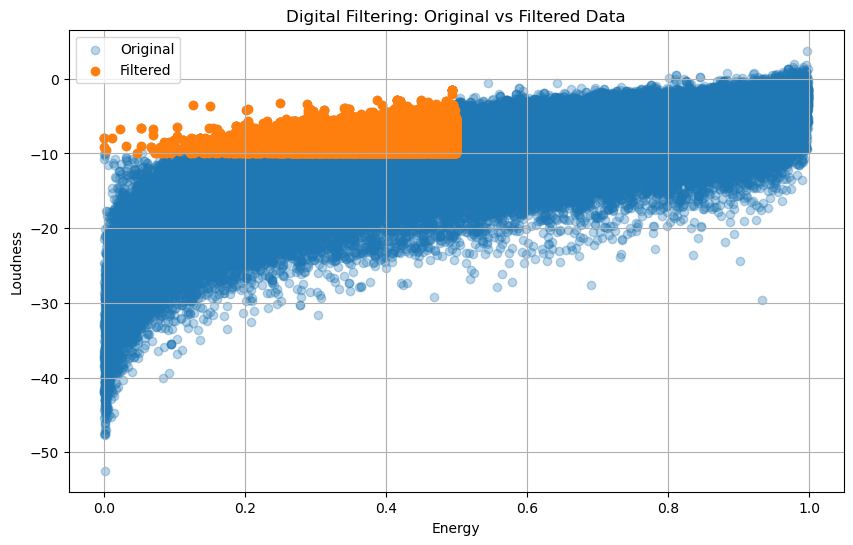

In [ ]:
plt.figure(figsize=(10,6))

# Original data
plt.scatter(df['energy'], df['loudness'], alpha=0.3, label='Original')

# Filtered data
plt.scatter(filtered_df['energy'], filtered_df['loudness'], label='Filtered')

plt.xlabel('Energy')
plt.ylabel('Loudness')
plt.title('Digital Filtering: Original vs Filtered Data')
plt.legend()
plt.grid()

plt.show()

The filtering process applies two threshold conditions: energy < 0.5 and loudness > -10 dB. The energy condition removes high-energy signals, meaning tracks with very strong intensity are excluded. Meanwhile, the loudness condition removes signals that are too quiet, ensuring that only sufficiently audible tracks remain. These thresholds act as boundaries that determine which signals are retained or discarded.

After applying the filters, the dataset becomes smaller compared to the original dataset. This indicates that some data points did not meet the specified conditions and were removed. As seen in the graph, the filtered data points are fewer and more concentrated within a specific region, showing that extreme values have been eliminated. This results in a dataset with more balanced and controlled signal characteristics.

In terms of Digital Signal Processing (DSP), this method is analogous to real filtering techniques. The condition energy < 0.5 behaves like a low-pass filter, removing high-intensity components, while loudness > -10 dB acts like a high-pass filter, removing weak signals. When combined, they function similarly to a band-pass filter, allowing only signals within a desired range to pass through while rejecting unwanted components.

In [ ]:
# Define step size
step = 10

# Apply quantization
df['tempo_quantized'] = (df['tempo'] // step) * step

df[['tempo', 'tempo_quantized']].head()

,tempo,tempo_quantized
0,166.969,160.0
1,174.003,170.0
2,99.488,90.0
3,171.758,170.0
4,140.576,140.0


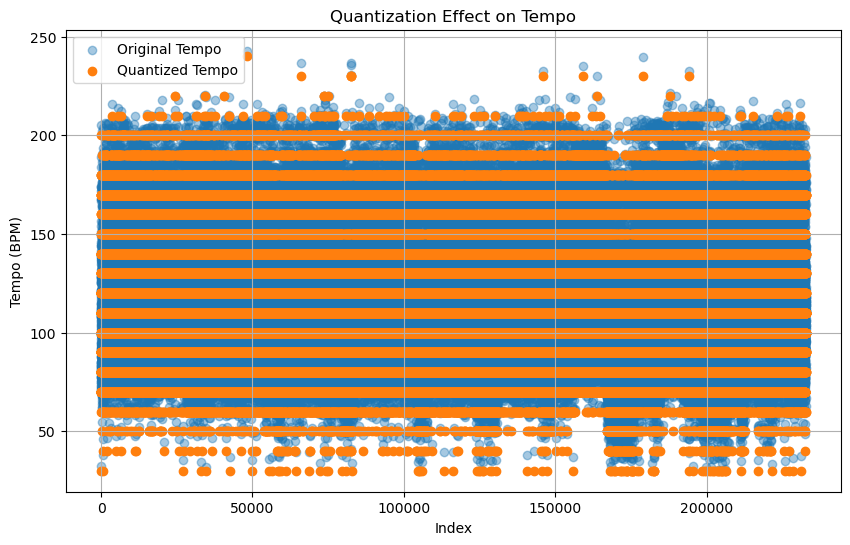

In [ ]:
plt.figure(figsize=(10,6))

# Original tempo
plt.scatter(range(len(df)), df['tempo'], alpha=0.4, label='Original Tempo')

# Quantized tempo
plt.scatter(range(len(df)), df['tempo_quantized'], label='Quantized Tempo')

plt.xlabel('Index')
plt.ylabel('Tempo (BPM)')
plt.title('Quantization Effect on Tempo')
plt.legend()
plt.grid()

plt.show()

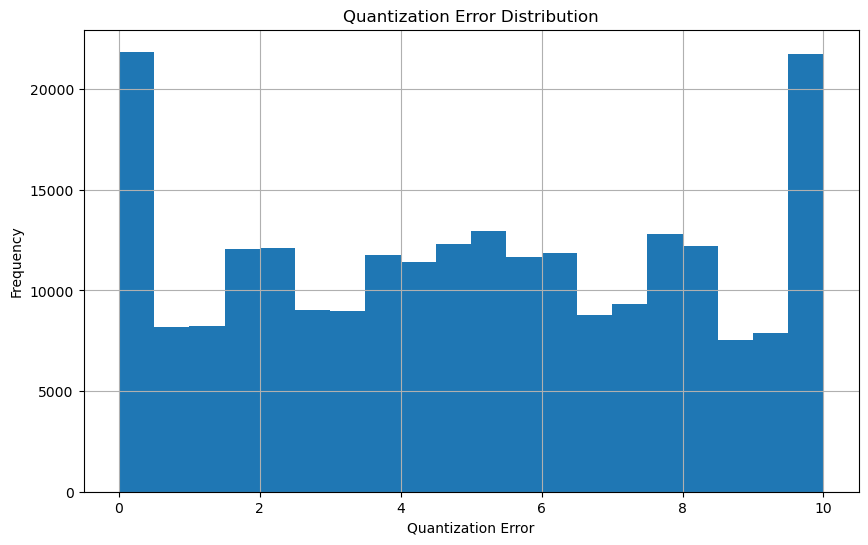

In [ ]:
# Compute error
df['quantization_error'] = df['tempo'] - df['tempo_quantized']

plt.figure(figsize=(10,6))

plt.hist(df['quantization_error'], bins=20)

plt.xlabel('Quantization Error')
plt.ylabel('Frequency')
plt.title('Quantization Error Distribution')
plt.grid()

plt.show()

Quantization was applied to the tempo feature using a step size of 10 BPM. This means that each tempo value is rounded down to the nearest multiple of 10, creating a new column of quantized values. This process simplifies the dataset by grouping similar tempo values into discrete levels.

From the graph, the original tempo values appear continuous and scattered, while the quantized values form distinct horizontal steps. This step-like pattern shows how continuous data is converted into discrete levels, which is a key concept in digital signal processing.

However, quantization introduces an error known as quantization error, which is the difference between the original tempo and the quantized value. This error represents the loss of information caused by rounding. The histogram of quantization error shows how these differences are distributed across the dataset.

There is a trade-off between accuracy and simplicity. A smaller step size would produce values closer to the original data, reducing error but increasing complexity. On the other hand, a larger step size simplifies the data but increases the loss of detail. This reflects a fundamental DSP principle: higher resolution provides more accurate signal representation, while lower resolution improves efficiency but reduces precision.